## Consumer Sentiment vs Consumer Consumption

In [1]:
import psutil
print(f"RAM used: {psutil.virtual_memory().percent}%")
print(f"RAM available: {psutil.virtual_memory().available / 1e9:.1f} GB")

RAM used: 79.7%
RAM available: 3.4 GB


### Preparation
---

#### Import statements

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import scipy.stats as stats



pd.options.display.float_format ="{:,.2f}".format

#### Load the Datasets

In [3]:
consumer_sentiment_df = pd.read_csv("./Datasets/UMCSENT.csv")
consumer_economic_conditions_df= pd.read_excel("./Datasets/Current_Economic_Conditions.xlsx")
consumer_expectations_df= pd.read_excel("./Datasets/Consumer_Expectations.xlsx")
real_consumption_expenditures_annual= pd.read_csv("Datasets/Real_Personal_Consumption_not_adjsuted_monthly.csv")
percent_change_monthly_adjusted = pd.read_csv("./Datasets/Percent_Change_Monthly_Adjsuted.csv")
percent_change_yearly_no_adjusted = pd.read_csv("./Datasets/Percnet_changeyearly_not_adjusted.csv")

### Initial checks
---

Use of the data is from 2000 onwards - so go to excel and remove the earlier values for ease.

<section class="data-checks">

  <h5>First Set of Checks</h5>
  <ul>
    <li>Head</li>
    <li>Tail</li>
    <li>Datatypes</li>
    <li>Columns</li>
    <li>Shape</li>
  </ul>

  <h5>Second Set of Checks</h5>
  <ul>
    <li>Remove unused columns</li>
    <li>Check duplicate values</li>
    <li>Missing values</li>
  </ul>
</section>


#### Consumer sentiment checks (Overall Sentiment)

In [4]:
#### first set of checks
consumer_sentiment_df.sample(5)         # Date is not the index - np
consumer_sentiment_df.head()            # Starts at the correct date
consumer_sentiment_df.tail()            # ends at 2026-01
consumer_sentiment_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_sentiment_df.dtypes            # Observation date needs to be converted

    #### Initial adjustments
consumer_sentiment_df.rename(columns={"observation_date":"Date","UMCSENT":"Sentiment_index"}, inplace=True)     # Fixed the index
consumer_sentiment_df["Date"]= pd.to_datetime(consumer_sentiment_df["Date"], format ="%d/%m/%Y")               # Datetime conversion but it is alsop in daily format so convert to thrifst of the mont



#### Second set of checks
consumer_sentiment_df.columns           #No need to drop columns
consumer_sentiment_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_sentiment_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_sentiment_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values

consumer_sentiment_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Sentiment_index
0,2000-01-01,112.00
1,2000-02-01,111.30
2,2000-03-01,107.10
3,2000-04-01,109.20
4,2000-05-01,110.70
...,...,...
308,2025-09-01,55.10
309,2025-10-01,53.60
310,2025-11-01,51.00
311,2025-12-01,52.90


#### Consumer Expectations checks

In [5]:
#### first set of checks
consumer_expectations_df.sample(5)
consumer_expectations_df.head(30)       # Starts at the correct date
consumer_expectations_df.tail()         # ends at 2026-01
consumer_expectations_df.dtypes          # Observation no need to be converted since its a datetime.
consumer_expectations_df.columns        # No spaces which is good but do need to rename  + No need to drop columns

    #### Initial adjustments
consumer_expectations_df.rename(columns={"Datemy":"Date","ICE":"Consumer_Expectations_index"}, inplace=True)     # Fixed the index

#### Second set of checks
consumer_expectations_df.columns           #Need to remove the recessions column

consumer_expectations_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_expectations_df.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_expectations_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    # There are no missing values( from geeks for geeeks)

    #### Adjustments
consumer_expectations_df.drop(columns=["RECESSION"], inplace=True)          ## Remove the recession column
consumer_expectations_df["Date"]= pd.to_datetime(consumer_expectations_df["Date"])
consumer_expectations_df


DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Consumer_Expectations_index
0,2000-01-01,103.60
1,2000-02-01,105.80
2,2000-03-01,106.00
3,2000-04-01,104.40
4,2000-05-01,103.40
...,...,...
309,2025-10-01,52.60
310,2025-11-01,51.00
311,2025-12-01,52.00
312,2026-01-01,54.20


#### Consumer Economic Conditions checks

In [6]:
#### first set of checks
consumer_economic_conditions_df.sample(5)         # Date is not the index - np
consumer_economic_conditions_df.head()            # Starts at the correct date
consumer_economic_conditions_df.tail()            # ends at 2026-02
consumer_economic_conditions_df.columns           # No spaces which is good but do need to rename  + No need to drop columns
consumer_economic_conditions_df.dtypes            # Npo changes needed

    #### Initial adjustments
consumer_economic_conditions_df.rename(columns={"Unnamed: 0":"Date","3mma":"Economic_Conditions_index"}, inplace=True)     # Fixed the index


#### Second set of checks
consumer_economic_conditions_df.columns           #Need to drop the recessions column
consumer_economic_conditions_df.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
consumer_economic_conditions_df.isna().sum()                                              # No missing values for any of the dates+ missing for recession + Need to check if all the 12 months are there

    # Adjustments
consumer_economic_conditions_df.drop(columns=["Recession"], inplace=True)       # Remove the Recession column
consumer_economic_conditions_df["Date"]= pd.to_datetime(consumer_economic_conditions_df["Date"])



        # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq="MS").difference(consumer_economic_conditions_df["Date"]))
                    # Sets up a date range, looks at the month start, then compares and then prints the ones that are different
                    ## There are no missing values
consumer_economic_conditions_df

DatetimeIndex([], dtype='datetime64[us]', freq='MS')


,Date,Economic_Conditions_index
0,2000-01-01,115.40
1,2000-02-01,115.40
2,2000-03-01,116.50
3,2000-04-01,116.70
4,2000-05-01,117.70
...,...,...
309,2025-10-01,60.20
310,2025-11-01,56.70
311,2025-12-01,53.40
312,2026-01-01,52.30


In [8]:
#### first set of checks
percent_change_monthly_adjusted.sample(5)         # Date is not the index - np
percent_change_monthly_adjusted.head()            # Starts at the correct date
percent_change_monthly_adjusted.tail()            # ends at 2025-01
percent_change_monthly_adjusted.columns           # No spaces which is good but do need to rename  + No need to drop columns
percent_change_monthly_adjusted.dtypes                           # Observation date needs to be converted

#     #### Initial adjustments
percent_change_monthly_adjusted.rename(columns={"observation_date":"Date","DPCERL1Q225SBEA":"Percentage_Change_Consumption"}, inplace=True)     # Fixed the index

percent_change_monthly_adjusted["Date"]= pd.to_datetime(percent_change_monthly_adjusted["Date"], format ="%d/%m/%Y")
percent_change_monthly_adjusted

#### Second set of checks
percent_change_monthly_adjusted.columns           #No need to drop columns
real_consumption_expenditures_annual.duplicated(subset="Date", keep=False).value_counts()      # All are false so no duplicated values
real_consumption_expenditures_annual.isna().sum()                                              # No missing values for any of the dates + Need to check if all the 12 months are there in the dataset

#         # Checks to make sure that all the dates are there for the period from 2000 to 2026.
print(len(pd.date_range(start= "2000-01-01", end = "2026-01-01", freq=" MS").difference(percent_change_monthly_adjusted["Date"])))
        # 209 dates missing for months out of 26 years ==== Need to clean the data at the end


209


### Main Clean dataset with all variables
---

In [10]:
#### Monthly Data

initial_df = pd.merge(consumer_economic_conditions_df, consumer_expectations_df, on="Date", how="inner")
clean_df1= pd.merge(initial_df,consumer_sentiment_df, on="Date", how="outer")
clean_df_monthly = pd.merge(clean_df1, percent_change_monthly_adjusted, on ="Date" , how = "outer")



clean_df_monthly.head(5)

clean_df_monthly.rename(columns= {"Economic_Conditions_index":"Economic_Conditions_Index",
                          "Consumer_Expectations_index":"Consumer_Expectations_Index",
                          "Sentiment_index":"Sentiment_Index",
                          "Percentage_Change_Consumption": "Percentage _Change_Consumption_Monthly",
                          "Consumption_Expenditures( Billions)": "Consumption_Expenditures",
                          "Percentage_Change_Consumption_Yearly":"Percentage_Change_Consumption_Yearly"}, inplace=True)
clean_df_monthly

,Date,Economic_Conditions_Index,Consumer_Expectations_Index,Sentiment_Index,Percentage _Change_Consumption_Monthly
0,2000-01-01,115.40,103.60,112.00,6.20
1,2000-02-01,115.40,105.80,111.30,NaN
2,2000-03-01,116.50,106.00,107.10,NaN
3,2000-04-01,116.70,104.40,109.20,3.80
4,2000-05-01,117.70,103.40,110.70,NaN
...,...,...,...,...,...
309,2025-10-01,60.20,52.60,53.60,2.00
310,2025-11-01,56.70,51.00,51.00,NaN
311,2025-12-01,53.40,52.00,52.90,NaN
312,2026-01-01,52.30,54.20,56.40,NaN


In [11]:
#### Yearly Data


clean_df_yearly= pd.merge(percent_change_yearly_no_adjusted, real_consumption_expenditures_annual, on ="Date" , how="outer")

clean_df_yearly.rename(columns= {
                          "Consumption_Expenditures( Billions)": "Consumption_Expenditures_Yearly",
                          "Percentage_Change_Consumption_Yearly":"Percentage_Change_Consumption_Yearly"}, inplace=True)

clean_df_yearly


,Date,Percentage_Change_Consumption_Yearly,Consumption_Expenditures_Yearly
0,2000-01-01,5.00,"9,166.88"
1,2001-01-01,2.50,"9,393.89"
2,2002-01-01,2.50,"9,632.77"
3,2003-01-01,3.20,"9,937.57"
4,2004-01-01,3.80,"10,312.21"
5,2005-01-01,3.50,"10,677.41"
6,2006-01-01,2.90,"10,986.77"
7,2007-01-01,2.40,"11,253.85"
8,2008-01-01,0.10,"11,270.74"
9,2009-01-01,-1.30,"11,123.60"


### Main Clean dataset with all variables( Z score)
---

In [12]:
## Monthly data Zscores
zscore_clean_df_monthly = pd.DataFrame({
    "Date": clean_df_monthly["Date"],
    "Economic_Conditions_Index": stats.zscore(clean_df_monthly["Economic_Conditions_Index"], nan_policy='omit'),
    "Consumer_Expectations_Index": stats.zscore(clean_df_monthly["Consumer_Expectations_Index"], nan_policy='omit'),
    "Sentiment_Index": stats.zscore(clean_df_monthly["Sentiment_Index"], nan_policy='omit'),
    "Percentage _Change_Consumption_Monthly": stats.zscore(clean_df_monthly["Percentage _Change_Consumption_Monthly"], nan_policy='omit' ),
})

zscore_clean_df_monthly

,Date,Economic_Conditions_Index,Consumer_Expectations_Index,Sentiment_Index,Percentage _Change_Consumption_Monthly
0,2000-01-01,1.36,2.31,2.16,0.66
1,2000-02-01,1.36,2.49,2.11,NaN
2,2000-03-01,1.43,2.50,1.81,NaN
3,2000-04-01,1.44,2.37,1.96,0.22
4,2000-05-01,1.50,2.29,2.07,NaN
...,...,...,...,...,...
309,2025-10-01,-1.88,-1.84,-2.02,-0.11
310,2025-11-01,-2.09,-1.98,-2.21,NaN
311,2025-12-01,-2.28,-1.89,-2.07,NaN
312,2026-01-01,-2.35,-1.71,-1.82,NaN


In [13]:
### Z score for yearly Variables

zscore_clean_df_yearly = pd.DataFrame({
    "Date": clean_df_yearly["Date"],
    "Percentage_Change_Consumption_Yearly": stats.zscore(clean_df_yearly["Percentage_Change_Consumption_Yearly"], nan_policy='omit'),
    "Consumption_Expenditures_Yearly": stats.zscore(clean_df_yearly["Consumption_Expenditures_Yearly"], nan_policy='omit'),

})

zscore_clean_df_yearly


,Date,Percentage_Change_Consumption_Yearly,Consumption_Expenditures_Yearly
0,2000-01-01,1.29,-1.54
1,2001-01-01,0.00,-1.43
2,2002-01-01,0.00,-1.31
3,2003-01-01,0.36,-1.16
4,2004-01-01,0.67,-0.98
5,2005-01-01,0.52,-0.80
6,2006-01-01,0.21,-0.65
7,2007-01-01,-0.05,-0.53
8,2008-01-01,-1.23,-0.52
9,2009-01-01,-1.94,-0.59


### Descriptive statistics
---

In [14]:
clean_df_monthly.describe()

,Date,Economic_Conditions_Index,Consumer_Expectations_Index,Sentiment_Index,Percentage _Change_Consumption_Monthly
count,314,314.00,314.00,313.00,104.00
mean,2013-01-15 04:03:03.439490,92.22,75.26,81.81,2.59
min,2000-01-01 00:00:00,52.30,49.30,50.00,-30.40
25%,2006-07-08 18:00:00,78.95,67.10,71.50,1.48
50%,2013-01-16 12:00:00,96.25,75.20,82.90,2.60
75%,2019-07-24 06:00:00,106.60,84.95,93.00,3.65
max,2026-02-01 00:00:00,117.70,106.00,112.00,40.60
std,NaN,17.04,12.30,13.97,5.49


In [15]:
zscore_clean_df_monthly.describe()

,Date,Economic_Conditions_Index,Consumer_Expectations_Index,Sentiment_Index,Percentage _Change_Consumption_Monthly
count,314,314.00,314.00,313.00,104.00
mean,2013-01-15 04:03:03.439490,0.00,0.00,0.00,-0.00
min,2000-01-01 00:00:00,-2.35,-2.11,-2.28,-6.04
25%,2006-07-08 18:00:00,-0.78,-0.66,-0.74,-0.20
50%,2013-01-16 12:00:00,0.24,-0.00,0.08,0.00
75%,2019-07-24 06:00:00,0.85,0.79,0.80,0.19
max,2026-02-01 00:00:00,1.50,2.50,2.16,6.96
std,NaN,1.00,1.00,1.00,1.00


In [16]:
clean_df_yearly

,Date,Percentage_Change_Consumption_Yearly,Consumption_Expenditures_Yearly
0,2000-01-01,5.00,"9,166.88"
1,2001-01-01,2.50,"9,393.89"
2,2002-01-01,2.50,"9,632.77"
3,2003-01-01,3.20,"9,937.57"
4,2004-01-01,3.80,"10,312.21"
5,2005-01-01,3.50,"10,677.41"
6,2006-01-01,2.90,"10,986.77"
7,2007-01-01,2.40,"11,253.85"
8,2008-01-01,0.10,"11,270.74"
9,2009-01-01,-1.30,"11,123.60"


In [17]:
zscore_clean_df_yearly

,Date,Percentage_Change_Consumption_Yearly,Consumption_Expenditures_Yearly
0,2000-01-01,1.29,-1.54
1,2001-01-01,0.00,-1.43
2,2002-01-01,0.00,-1.31
3,2003-01-01,0.36,-1.16
4,2004-01-01,0.67,-0.98
5,2005-01-01,0.52,-0.80
6,2006-01-01,0.21,-0.65
7,2007-01-01,-0.05,-0.53
8,2008-01-01,-1.23,-0.52
9,2009-01-01,-1.94,-0.59


### Visualisation
---

##### Overall Sentiment to Overall Consumption

NameError: name 'clean_df' is not defined

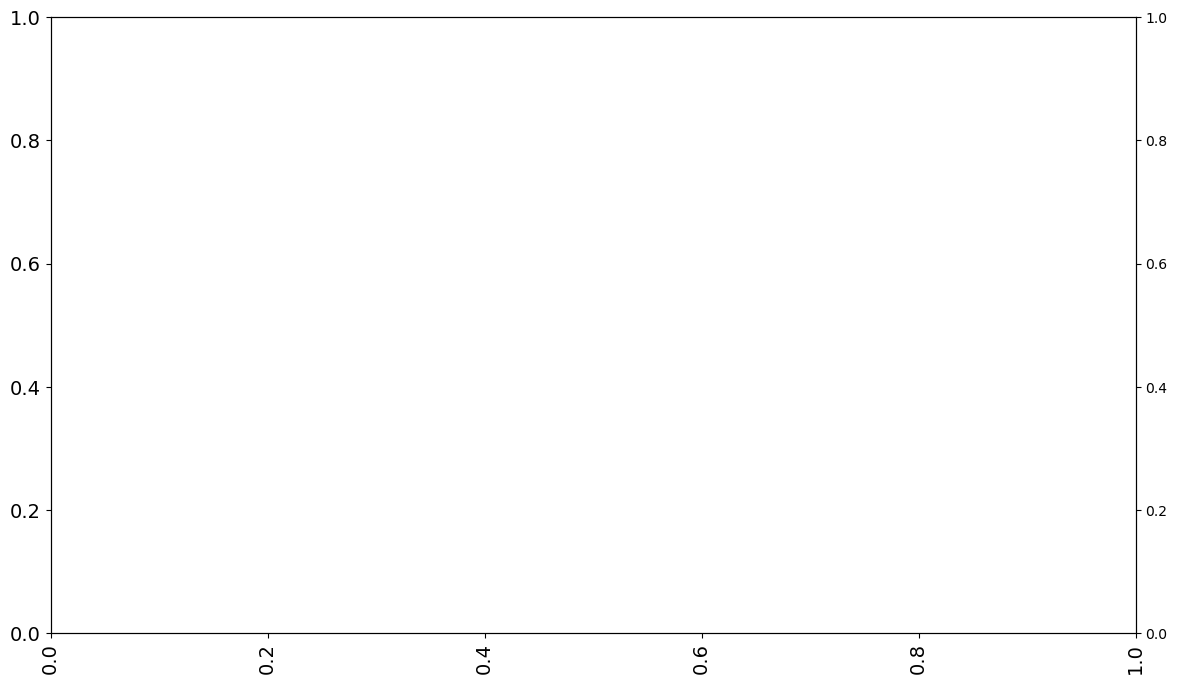

In [18]:
## Plot
    ## Initial features
plt.figure(figsize=(14,8))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()
    ## Plots
ax1.plot(clean_df["Date"],
         clean_df["Sentiment_Index"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")

ax2.plot(real_consumption_expenditures_annual["Date"],
         real_consumption_expenditures_annual["Consumption_Expenditures"],
         color="Red",
         linewidth=2,
         label="Consumption_Expenditures( Billions)")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)


    ## Final features

ax1.set_xlabel("Date")
ax1.set_ylabel("Sentiment Index")
ax2.set_ylabel("Consumption Expenditures( Billions)")
plt.title("Consumer Sentiment Index 2000-2026", fontsize=16)
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))
fig = plt.gcf()
fig.legend()
plt.show()


Consumption is steadily rising compared to sentiment -- so the variables seem decoupled. Try the percent changes.


What about growth rates of consumption ?


##### Sentiment to Percentage change in consumption( Z Scores)

In [ ]:
aligned_df = zscore_clean_df[["Date", "Sentiment_index", "Percentage_Change_Monthly"]].dropna()
## Plot

plt.figure(figsize=(14,8))


plt.subplot(2, 1, 1)
plt.plot(zscore_clean_df["Date"],
         zscore_clean_df["Sentiment_index"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Sentiment Z- Scores')
plt.xlabel('Date')
plt.ylabel('Z-Score')


plt.subplots_adjust(hspace=0.4)  # vertical gap (height)


plt.subplot(2, 1, 2)
plt.plot(aligned_df["Date"],
         aligned_df["Percentage_Change_Monthly"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Z-Score')
plt.xlabel('Date')
plt.ylabel('Consumption Z-Score')


##### Percentage change in consumption onto Consumer Economic Conditions + Consumer Expectations( Monthly consumption data)

In [ ]:
aligned_df = zscore_clean_df[["Date","Economic_Conditions_index", "Consumer_Expectations_index"	, "Sentiment_index", "Percentage_Change_Monthly"]].dropna()
## Plot

plt.figure(figsize=(14,8))


plt.subplot(2, 2, 1)
plt.plot(aligned_df["Date"],
         aligned_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions Z score")
plt.title('Economic Conditions Z- Scores')
plt.xlabel('Date')
plt.ylabel('Z-Score')

plt.subplot(2, 2, 2)
plt.plot(aligned_df["Date"],
         aligned_df["Consumer_Expectations_index"],
         color="Blue",
         linewidth=2,
         label="Consumer Expectations Z score")
plt.title('Consumer Expectations Z- Scores')
plt.xlabel('Date')
plt.ylabel('Z-Score')


plt.subplots_adjust(hspace=0.4)  # vertical gap (height)


plt.subplot(2, 2, 3)
plt.plot(aligned_df["Date"],
         aligned_df["Percentage_Change_Monthly"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Z-Score')
plt.xlabel('Date')
plt.ylabel('Consumption Z-Score')

plt.subplot(2, 2, 4)
plt.plot(aligned_df["Date"],
         aligned_df["Percentage_Change_Monthly"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Z-Score')
plt.xlabel('Date')
plt.ylabel('Consumption Z-Score')

##### Percentage change in consumption onto Consumer Economic Conditions + Consumer Expectations( Yearly consumption data)

In [ ]:
aligned_df = zscore_clean_df[["Date","Economic_Conditions_index", "Consumer_Expectations_index"	, "Sentiment_index","Percentage_Change_Monthly", "Percentage_change_Yearly"]].dropna()
## Plot

plt.figure(figsize=(14,8))


plt.subplot(2, 2, 1)
plt.plot(aligned_df["Date"],
         aligned_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions Z score")
plt.title('Economic Conditions Z- Scores')
plt.xlabel('Date')
plt.ylabel('Z-Score')

plt.subplot(2, 2, 2)
plt.plot(aligned_df["Date"],
         aligned_df["Consumer_Expectations_index"],
         color="Blue",
         linewidth=2,
         label="Consumer Expectations Z score")
plt.title('Consumer Expectations Z- Scores')
plt.xlabel('Date')
plt.ylabel('Z-Score')


plt.subplots_adjust(hspace=0.4)  # vertical gap (height)


plt.subplot(2, 2, 3)
plt.plot(aligned_df["Date"],
         aligned_df["Percentage_change_Yearly"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Z-Score( Yearly)')
plt.xlabel('Date')
plt.ylabel('Consumption Z-Score( Yearly)')

plt.subplot(2, 2, 4)
plt.plot(aligned_df["Date"],
         aligned_df["Percentage_change_Yearly"],
         color="Blue",
         linewidth=2,
         label="Sentiment_index")
plt.title('Consumption Z-Score( Yearly)')
plt.xlabel('Date')
plt.ylabel('Consumption Z-Score( Yearly)')

##### Consumer Economic Conditions vs Consumer Expectations

In [ ]:
## Plot
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14, rotation = 90)
plt.yticks(fontsize=14)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(clean_df["Date"],
         clean_df["Economic_Conditions_index"],
         color="Blue",
         linewidth=2,
         label="Economic Conditions")
ax2.plot(clean_df["Date"],
         clean_df["Consumer_Expectations_index"],
         color="Red",
         linewidth=2,
         label="Consumer Expectations")

    ## Adding in the date functionalities
Year = mdates.YearLocator()
Months = mdates.MonthLocator()
Years_FMT = mdates.DateFormatter('%Y')

ax1.xaxis.set_major_locator(Year)
ax1.xaxis.set_minor_locator(Months)
ax1.xaxis.set_major_formatter(Years_FMT)





ax1.set_xlabel("Date")
ax1.set_ylabel("Economic Conditions")
ax2.set_ylabel("Consumer Expectations")
plt.xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2026-01-01"))

plt.title("Consumer Economic Conditions vs Consumer Expectations", fontsize=16)
fig= plt.gcf()
fig.legend()
fig.show()